,count,missing %,mean,median,std,min,max,skew,outliers %
column,,,,,,,,,
age,300,0.00,34.58,35.00,9.52,18.00,73.00,0.39,0.70
income,270,10.00,85604.05,34302.15,388588.56,544.84,5000000.00,11.40,5.20
score,290,3.30,69.79,70.33,14.88,29.55,109.49,-0.00,1.70


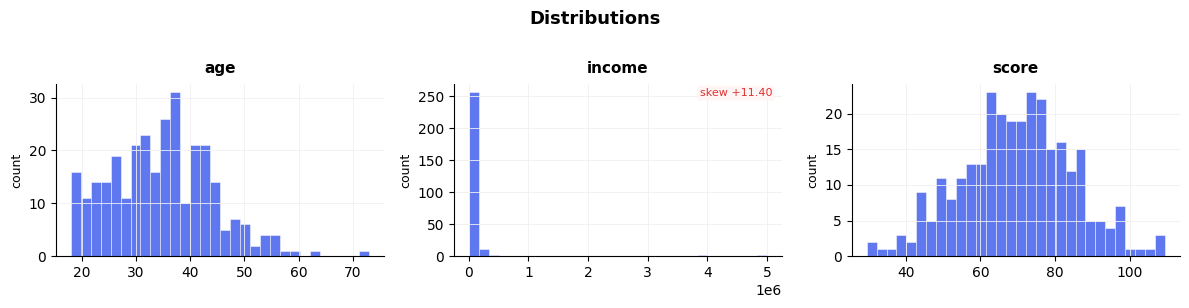

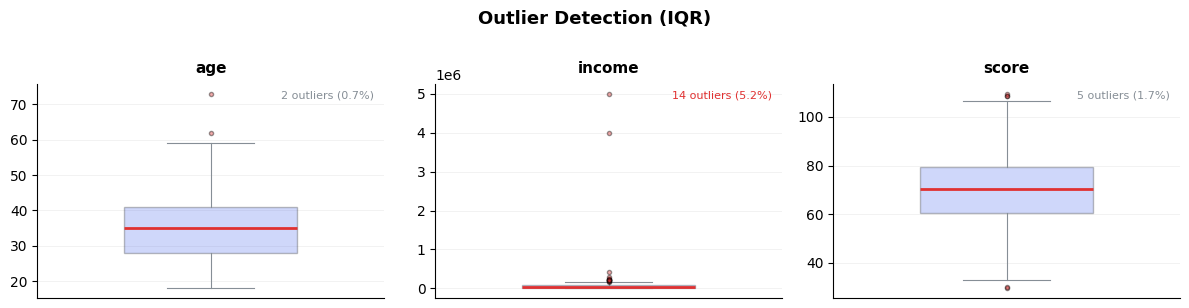

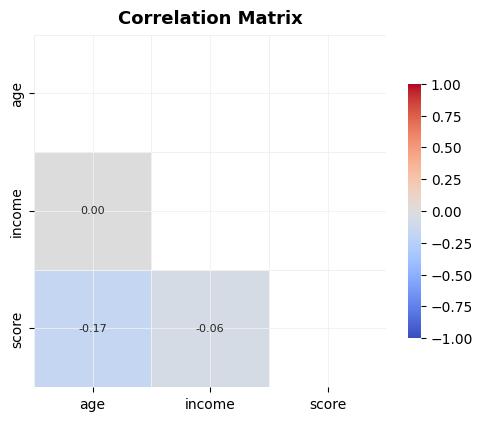

In [2]:
import pandas as pd
import numpy as np
import quick_eda

# synthetic messy dataset
np.random.seed(42)
n = 300

df = pd.DataFrame({
    "user_id":   range(n),
    "age":       np.random.normal(35, 10, n).clip(18, 80).astype(int),
    "income":    np.random.exponential(50000, n),
    "status":    ["active"] * 295 + ["inactive"] * 5,
    "score":     np.random.normal(70, 15, n),
    "category":  np.random.choice([f"cat_{i}" for i in range(60)], n),
    "constant":  [1] * n,
    "signup":    pd.date_range("2020-01-01", periods=n, freq="D"),
})

# inject missing values
df.loc[np.random.choice(n, 30, replace=False), "income"] = np.nan
df.loc[np.random.choice(n, 10, replace=False), "score"]  = np.nan

# inject outliers
df.loc[0, "income"] = 5_000_000
df.loc[1, "income"] = 4_000_000

quick_eda.quick_eda(df)